# Simple CNN

In [1]:
!pip install wandb kaggle -q

In [2]:
from google.colab import userdata
import os
import wandb

wandb.login(key=userdata.get('WANDB_API_KEY'))
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gdzag22 (gdzag22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip

100% 285M/285M [00:01<00:00, 199MB/s]



# Data Loading

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

df = pd.read_csv('icml_face_data.csv')
df.columns = df.columns.str.strip()

train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Device:", device)

Train: 28709 Val: 3589 Test: 3589
Device: cuda


In [5]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        pixels = np.array(self.dataframe.iloc[idx]['pixels'].split(),
                          dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)
        if self.transform:
            image = self.transform(image)
        label = int(self.dataframe.iloc[idx]['emotion'])
        return image, label

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = FERDataset(train_df, transform=basic_transform)
val_dataset = FERDataset(val_df,   transform=basic_transform)
test_dataset = FERDataset(test_df,  transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("one batch shape:", next(iter(train_loader))[0].shape)

one batch shape: torch.Size([64, 1, 48, 48])


# Forward Sanity Check

In [6]:
expected_loss = np.log(7)
print(f"Expected initial loss: {expected_loss:.4f}")

test_model = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * 48 * 48, 7)
).to(device)

images, labels = next(iter(train_loader))
images,labels = images.to(device), labels.to(device)

with torch.no_grad():
    out = test_model(images)
    loss = nn.CrossEntropyLoss()(out, labels)

print(f"Actual initial loss:   {loss.item():.4f}")

Expected initial loss: 1.9459
Actual initial loss:   1.9754


In [ ]:
# backward
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

small_images = images[:10]
small_labels = labels[:10]

optimizer_test = torch.optim.Adam(test_model.parameters(), lr=0.01)
losses = []
for step in range(200):
    optimizer_test.zero_grad()
    out = test_model(small_images)
    loss = nn.CrossEntropyLoss()(out, small_labels)
    loss.backward()
    optimizer_test.step()
    losses.append(loss.item())

print(f"Loss after overfitting 10 samples: {losses[-1]:.4f}")

# Training Utilities

In [7]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0,0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


def run_experiment(model, run_name, epochs=30, lr=0.001, optimizer_name='Adam'):
    run = wandb.init(
        project="facial_expression_recognition",
        group="SimpleCNN",
        name=run_name,
        config={
            'epochs': epochs,
            'lr': lr,
            'optimizer': optimizer_name,
            'batch_size': 64
        }
    )

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD_Momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'NAG':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    np.save(f'{run_name}.npy', [train_accs, val_accs, train_losses, val_losses])

    wandb.finish()
    return train_accs, val_accs, train_losses, val_losses

# Training

### Single Conv Layer

In [9]:
# just one conv layer

class CNN_v1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(32 * 24 * 24, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_v1 = CNN_v1().to(device)
v1_train_accs, v1_val_accs, v1_train_losses, v1_val_losses = run_experiment(
    model_v1, 'SimpleCNN_v1_single_conv', epochs=30, lr=0.001
)

Epoch 1/30 | Train Acc: 0.3667 | Val Acc: 0.4143
Epoch 2/30 | Train Acc: 0.4625 | Val Acc: 0.4561
Epoch 3/30 | Train Acc: 0.5032 | Val Acc: 0.4542
Epoch 4/30 | Train Acc: 0.5261 | Val Acc: 0.4717
Epoch 5/30 | Train Acc: 0.5515 | Val Acc: 0.4728
Epoch 6/30 | Train Acc: 0.5690 | Val Acc: 0.4804
Epoch 7/30 | Train Acc: 0.5824 | Val Acc: 0.4650
Epoch 8/30 | Train Acc: 0.6018 | Val Acc: 0.4753
Epoch 9/30 | Train Acc: 0.6170 | Val Acc: 0.4717
Epoch 10/30 | Train Acc: 0.6327 | Val Acc: 0.4695
Epoch 11/30 | Train Acc: 0.6447 | Val Acc: 0.4806
Epoch 12/30 | Train Acc: 0.6576 | Val Acc: 0.4751
Epoch 13/30 | Train Acc: 0.6705 | Val Acc: 0.4673
Epoch 14/30 | Train Acc: 0.6847 | Val Acc: 0.4570
Epoch 15/30 | Train Acc: 0.6963 | Val Acc: 0.4673
Epoch 16/30 | Train Acc: 0.7116 | Val Acc: 0.4642
Epoch 17/30 | Train Acc: 0.7226 | Val Acc: 0.4533
Epoch 18/30 | Train Acc: 0.7316 | Val Acc: 0.4667
Epoch 19/30 | Train Acc: 0.7430 | Val Acc: 0.4570
Epoch 20/30 | Train Acc: 0.7577 | Val Acc: 0.4692
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,█▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▅▅▇▇█▆▇▇▇█▇▇▅▇▆▅▇▅▇▇▇▄▅▅▄▅▅▅▄
val_loss,▂▁▂▁▁▁▂▁▁▂▂▃▂▃▂▃▃▄▄▄▄▅▆▇▆▇▇▇██
epoch,30
train_acc,0.84186
train_loss,0.48249
val_acc,0.44525
val_loss,2.03937


### Two Conv Layers

In [10]:
class CNN_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 12 * 12, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_v2 = CNN_v2().to(device)
v2_train_accs, v2_val_accs, v2_train_losses, v2_val_losses = run_experiment(
    model_v2, 'SimpleCNN_v2_two_conv', epochs=30, lr=0.001
)

Epoch 1/30 | Train Acc: 0.3937 | Val Acc: 0.4653
Epoch 2/30 | Train Acc: 0.4917 | Val Acc: 0.4982
Epoch 3/30 | Train Acc: 0.5380 | Val Acc: 0.5138
Epoch 4/30 | Train Acc: 0.5710 | Val Acc: 0.5183
Epoch 5/30 | Train Acc: 0.5994 | Val Acc: 0.5347
Epoch 6/30 | Train Acc: 0.6272 | Val Acc: 0.5378
Epoch 7/30 | Train Acc: 0.6497 | Val Acc: 0.5222
Epoch 8/30 | Train Acc: 0.6699 | Val Acc: 0.5369
Epoch 9/30 | Train Acc: 0.6900 | Val Acc: 0.5297
Epoch 10/30 | Train Acc: 0.7013 | Val Acc: 0.5266
Epoch 11/30 | Train Acc: 0.7191 | Val Acc: 0.5305
Epoch 12/30 | Train Acc: 0.7306 | Val Acc: 0.5269
Epoch 13/30 | Train Acc: 0.7470 | Val Acc: 0.5157
Epoch 14/30 | Train Acc: 0.7591 | Val Acc: 0.5252
Epoch 15/30 | Train Acc: 0.7708 | Val Acc: 0.5141
Epoch 16/30 | Train Acc: 0.7778 | Val Acc: 0.5077
Epoch 17/30 | Train Acc: 0.7894 | Val Acc: 0.4996
Epoch 18/30 | Train Acc: 0.7990 | Val Acc: 0.5113
Epoch 19/30 | Train Acc: 0.8096 | Val Acc: 0.5177
Epoch 20/30 | Train Acc: 0.8161 | Val Acc: 0.5104
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███████
train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▆▆██▆█▇▇▇▇▆▇▆▅▄▅▆▅▅▅▅▅▅▅▅▅▅▄
val_loss,▂▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▅▅▅▆▆▆▇▇██
epoch,30
train_acc,0.8785
train_loss,0.35086
val_acc,0.50014
val_loss,2.47824


### Three conv layers + Batchnorm + dropout

In [11]:
class CNN_v3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(128 * 6 * 6, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x =self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

model_v3 = CNN_v3().to(device)
v3_train_accs, v3_val_accs, v3_train_losses, v3_val_losses = run_experiment(
    model_v3, 'SimpleCNN_v3_three_conv_bn_dropout', epochs=30, lr=0.001
)

Epoch 1/30 | Train Acc: 0.3888 | Val Acc: 0.4628
Epoch 2/30 | Train Acc: 0.4906 | Val Acc: 0.5261
Epoch 3/30 | Train Acc: 0.5298 | Val Acc: 0.5222
Epoch 4/30 | Train Acc: 0.5623 | Val Acc: 0.5508
Epoch 5/30 | Train Acc: 0.5869 | Val Acc: 0.5673
Epoch 6/30 | Train Acc: 0.6125 | Val Acc: 0.5759
Epoch 7/30 | Train Acc: 0.6286 | Val Acc: 0.5882
Epoch 8/30 | Train Acc: 0.6531 | Val Acc: 0.5907
Epoch 9/30 | Train Acc: 0.6685 | Val Acc: 0.5918
Epoch 10/30 | Train Acc: 0.6868 | Val Acc: 0.5779
Epoch 11/30 | Train Acc: 0.7092 | Val Acc: 0.5899
Epoch 12/30 | Train Acc: 0.7255 | Val Acc: 0.5885
Epoch 13/30 | Train Acc: 0.7423 | Val Acc: 0.5868
Epoch 14/30 | Train Acc: 0.7561 | Val Acc: 0.5926
Epoch 15/30 | Train Acc: 0.7728 | Val Acc: 0.5924
Epoch 16/30 | Train Acc: 0.7871 | Val Acc: 0.5807
Epoch 17/30 | Train Acc: 0.7979 | Val Acc: 0.5868
Epoch 18/30 | Train Acc: 0.8099 | Val Acc: 0.5770
Epoch 19/30 | Train Acc: 0.8186 | Val Acc: 0.5773
Epoch 20/30 | Train Acc: 0.8279 | Val Acc: 0.5890
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████████
train_loss,█▇▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▄▆▇▇███▇█████▇█▇▇█▇▇▇██▇▇█▇▇
val_loss,▆▃▃▂▂▁▁▁▁▁▁▁▂▂▂▃▃▄▄▄▅▄▅▅▆▇▇▇▇█
epoch,30
train_acc,0.89049
train_loss,0.30988
val_acc,0.56673
val_loss,1.53677


### data augmentation

In [12]:
augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset_aug = FERDataset(train_df, transform=augmented_transform)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

def run_experiment_aug(model, run_name, epochs=30, lr=0.001):
    run = wandb.init(
        project="facial_expression_recognition",
        group="SimpleCNN",
        name=run_name,
        config={
            'epochs': epochs,
            'lr': lr,
            'optimizer': 'Adam',
            'batch_size': 64,
            'augmentation': True
        }
    )

    criterion = nn.CrossEntropyLoss()
    optimizer= torch.optim.Adam(model.parameters(), lr=lr)

    train_accs, val_accs,train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader_aug, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    np.save(f'{run_name}.npy', [train_accs, val_accs, train_losses, val_losses])
    wandb.finish()
    return train_accs, val_accs, train_losses, val_losses

model_v3_aug = CNN_v3().to(device)
v3_aug_train_accs, v3_aug_val_accs, v3_aug_train_losses, v3_aug_val_losses = run_experiment_aug(
    model_v3_aug, 'SimpleCNN_v3_augmentation', epochs=30, lr=0.001
)

Epoch 1/30 | Train Acc: 0.3205 | Val Acc: 0.4302
Epoch 2/30 | Train Acc: 0.4259 | Val Acc: 0.4795
Epoch 3/30 | Train Acc: 0.4642 | Val Acc: 0.5068
Epoch 4/30 | Train Acc: 0.4877 | Val Acc: 0.4912
Epoch 5/30 | Train Acc: 0.5051 | Val Acc: 0.5369
Epoch 6/30 | Train Acc: 0.5189 | Val Acc: 0.5511
Epoch 7/30 | Train Acc: 0.5297 | Val Acc: 0.5614
Epoch 8/30 | Train Acc: 0.5368 | Val Acc: 0.5678
Epoch 9/30 | Train Acc: 0.5437 | Val Acc: 0.5754
Epoch 10/30 | Train Acc: 0.5545 | Val Acc: 0.5793
Epoch 11/30 | Train Acc: 0.5578 | Val Acc: 0.5807
Epoch 12/30 | Train Acc: 0.5684 | Val Acc: 0.5784
Epoch 13/30 | Train Acc: 0.5741 | Val Acc: 0.5871
Epoch 14/30 | Train Acc: 0.5745 | Val Acc: 0.5887
Epoch 15/30 | Train Acc: 0.5775 | Val Acc: 0.5901
Epoch 16/30 | Train Acc: 0.5809 | Val Acc: 0.5965
Epoch 17/30 | Train Acc: 0.5834 | Val Acc: 0.5899
Epoch 18/30 | Train Acc: 0.5889 | Val Acc: 0.5904
Epoch 19/30 | Train Acc: 0.5944 | Val Acc: 0.5821
Epoch 20/30 | Train Acc: 0.5905 | Val Acc: 0.6032
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█▇██████████
train_loss,█▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▃▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇█████████
val_loss,█▆▅▆▄▃▃▃▃▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train_acc,0.61357
train_loss,1.03294
val_acc,0.60769
val_loss,1.05434


### Learning rate comparison

In [13]:
for lr in [0.01, 0.0001]:
    model = CNN_v3().to(device)
    run_experiment_aug(model, f'SimpleCNN_v3_aug_lr{lr}', epochs=30, lr=lr)

Epoch 1/30 | Train Acc: 0.2888 | Val Acc: 0.3714
Epoch 2/30 | Train Acc: 0.3972 | Val Acc: 0.4553
Epoch 3/30 | Train Acc: 0.4457 | Val Acc: 0.4762
Epoch 4/30 | Train Acc: 0.4723 | Val Acc: 0.5247
Epoch 5/30 | Train Acc: 0.4910 | Val Acc: 0.5272
Epoch 6/30 | Train Acc: 0.4983 | Val Acc: 0.5422
Epoch 7/30 | Train Acc: 0.5068 | Val Acc: 0.5316
Epoch 8/30 | Train Acc: 0.5151 | Val Acc: 0.5570
Epoch 9/30 | Train Acc: 0.5143 | Val Acc: 0.5336
Epoch 10/30 | Train Acc: 0.5199 | Val Acc: 0.5380
Epoch 11/30 | Train Acc: 0.5246 | Val Acc: 0.5550
Epoch 12/30 | Train Acc: 0.5252 | Val Acc: 0.5592
Epoch 13/30 | Train Acc: 0.5328 | Val Acc: 0.5573
Epoch 14/30 | Train Acc: 0.5323 | Val Acc: 0.5600
Epoch 15/30 | Train Acc: 0.5331 | Val Acc: 0.5556
Epoch 16/30 | Train Acc: 0.5369 | Val Acc: 0.5570
Epoch 17/30 | Train Acc: 0.5404 | Val Acc: 0.5765
Epoch 18/30 | Train Acc: 0.5382 | Val Acc: 0.5662
Epoch 19/30 | Train Acc: 0.5380 | Val Acc: 0.5405
Epoch 20/30 | Train Acc: 0.5438 | Val Acc: 0.5681
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇███████████
train_loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇▆▇▆▇▇▇▇▇▇▇██▇███▇█████▇█
val_loss,█▆▆▃▃▃▃▂▃▂▂▂▃▂▂▂▁▂▂▁▂▁▂▂▂▁▁▁▂▁
epoch,30
train_acc,0.55059
train_loss,1.18355
val_acc,0.57175
val_loss,1.13696


Epoch 1/30 | Train Acc: 0.2832 | Val Acc: 0.3697
Epoch 2/30 | Train Acc: 0.3497 | Val Acc: 0.4218
Epoch 3/30 | Train Acc: 0.3871 | Val Acc: 0.4558
Epoch 4/30 | Train Acc: 0.4125 | Val Acc: 0.4843
Epoch 5/30 | Train Acc: 0.4316 | Val Acc: 0.4678
Epoch 6/30 | Train Acc: 0.4432 | Val Acc: 0.4815
Epoch 7/30 | Train Acc: 0.4522 | Val Acc: 0.4965
Epoch 8/30 | Train Acc: 0.4615 | Val Acc: 0.4948
Epoch 9/30 | Train Acc: 0.4713 | Val Acc: 0.5116
Epoch 10/30 | Train Acc: 0.4763 | Val Acc: 0.5219
Epoch 11/30 | Train Acc: 0.4805 | Val Acc: 0.5319
Epoch 12/30 | Train Acc: 0.4907 | Val Acc: 0.5208
Epoch 13/30 | Train Acc: 0.4920 | Val Acc: 0.5141
Epoch 14/30 | Train Acc: 0.4974 | Val Acc: 0.5300
Epoch 15/30 | Train Acc: 0.5005 | Val Acc: 0.5277
Epoch 16/30 | Train Acc: 0.5026 | Val Acc: 0.5305
Epoch 17/30 | Train Acc: 0.5098 | Val Acc: 0.5280
Epoch 18/30 | Train Acc: 0.5117 | Val Acc: 0.5341
Epoch 19/30 | Train Acc: 0.5157 | Val Acc: 0.5414
Epoch 20/30 | Train Acc: 0.5199 | Val Acc: 0.5269
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
train_loss,█▇▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▅▆▆▆▆▇▆▆▇▇▇▇▇▇▇██████▇███
val_loss,█▇▅▄▅▄▄▃▃▃▂▃▃▂▂▂▂▂▂▂▁▁▁▂▁▁▂▁▁▁
epoch,30
train_acc,0.54196
train_loss,1.21806
val_acc,0.55475
val_loss,1.18471


### optimizer comparison

In [14]:
for opt in ['SGD_Momentum', 'NAG']:
    model = CNN_v3().to(device)

    run = wandb.init(
        project="facial_expression_recognition",
        group="SimpleCNN",
        name=f'SimpleCNN_v3_aug_{opt}',
        config={
            'epochs': 30,
            'lr': 0.01,
            'optimizer': opt,
            'augmentation': True
        }
    )

    criterion = nn.CrossEntropyLoss()

    if opt == 'SGD_Momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif opt == 'NAG':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

    train_accs, val_accs = [], []

    for epoch in range(30):
        train_loss,train_acc = train_epoch(model, train_loader_aug, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        print(f"[{opt}] Epoch {epoch+1}/30 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    np.save(f'SimpleCNN_v3_aug_{opt}.npy', [train_accs, val_accs])
    wandb.finish()

[SGD_Momentum] Epoch 1/30 | Train Acc: 0.2564 | Val Acc: 0.3174
[SGD_Momentum] Epoch 2/30 | Train Acc: 0.2941 | Val Acc: 0.3160
[SGD_Momentum] Epoch 3/30 | Train Acc: 0.3244 | Val Acc: 0.3625
[SGD_Momentum] Epoch 4/30 | Train Acc: 0.3606 | Val Acc: 0.4193
[SGD_Momentum] Epoch 5/30 | Train Acc: 0.3972 | Val Acc: 0.4427
[SGD_Momentum] Epoch 6/30 | Train Acc: 0.4366 | Val Acc: 0.4817
[SGD_Momentum] Epoch 7/30 | Train Acc: 0.4596 | Val Acc: 0.4996
[SGD_Momentum] Epoch 8/30 | Train Acc: 0.4767 | Val Acc: 0.5032
[SGD_Momentum] Epoch 9/30 | Train Acc: 0.4953 | Val Acc: 0.5216
[SGD_Momentum] Epoch 10/30 | Train Acc: 0.4990 | Val Acc: 0.5280
[SGD_Momentum] Epoch 11/30 | Train Acc: 0.5155 | Val Acc: 0.5130
[SGD_Momentum] Epoch 12/30 | Train Acc: 0.5201 | Val Acc: 0.5430
[SGD_Momentum] Epoch 13/30 | Train Acc: 0.5283 | Val Acc: 0.5539
[SGD_Momentum] Epoch 14/30 | Train Acc: 0.5344 | Val Acc: 0.5584
[SGD_Momentum] Epoch 15/30 | Train Acc: 0.5391 | Val Acc: 0.5578
[SGD_Momentum] Epoch 16/30 | Train

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train_loss,█▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
val_loss,██▇▆▅▄▄▃▃▃▄▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁
epoch,30
train_acc,0.58773
train_loss,1.09721
val_acc,0.60156
val_loss,1.05474


[NAG] Epoch 1/30 | Train Acc: 0.2585 | Val Acc: 0.3360
[NAG] Epoch 2/30 | Train Acc: 0.3409 | Val Acc: 0.4023
[NAG] Epoch 3/30 | Train Acc: 0.4014 | Val Acc: 0.4500
[NAG] Epoch 4/30 | Train Acc: 0.4431 | Val Acc: 0.4784
[NAG] Epoch 5/30 | Train Acc: 0.4661 | Val Acc: 0.4962
[NAG] Epoch 6/30 | Train Acc: 0.4825 | Val Acc: 0.5096
[NAG] Epoch 7/30 | Train Acc: 0.4997 | Val Acc: 0.5149
[NAG] Epoch 8/30 | Train Acc: 0.5100 | Val Acc: 0.5308
[NAG] Epoch 9/30 | Train Acc: 0.5196 | Val Acc: 0.5378
[NAG] Epoch 10/30 | Train Acc: 0.5299 | Val Acc: 0.5497
[NAG] Epoch 11/30 | Train Acc: 0.5368 | Val Acc: 0.5542
[NAG] Epoch 12/30 | Train Acc: 0.5430 | Val Acc: 0.5676
[NAG] Epoch 13/30 | Train Acc: 0.5509 | Val Acc: 0.5623
[NAG] Epoch 14/30 | Train Acc: 0.5529 | Val Acc: 0.5695
[NAG] Epoch 15/30 | Train Acc: 0.5577 | Val Acc: 0.5673
[NAG] Epoch 16/30 | Train Acc: 0.5618 | Val Acc: 0.5834
[NAG] Epoch 17/30 | Train Acc: 0.5668 | Val Acc: 0.5874
[NAG] Epoch 18/30 | Train Acc: 0.5725 | Val Acc: 0.5770
[

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇████████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇█▇▇███████████
val_loss,█▇▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▂▁▁▁▁
epoch,30
train_acc,0.59831
train_loss,1.07706
val_acc,0.59794
val_loss,1.07633


### Learning rate schedulers

In [15]:
def run_experiment_scheduler(model, run_name, scheduler_name, epochs=30, lr=0.001):
    run = wandb.init(
        project="facial_expression_recognition",
        group="SimpleCNN",
        name=run_name,
        config={
            'epochs': epochs,
            'lr': lr,
            'optimizer': 'Adam',
            'scheduler': scheduler_name,
            'augmentation': True
        }
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if scheduler_name == 'StepLR':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    elif scheduler_name == 'CosineAnnealing':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader_aug, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step()
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })

        print(f"[{scheduler_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    np.save(f'{run_name}.npy', [train_accs, val_accs, train_losses, val_losses])
    wandb.finish()
    return train_accs, val_accs, train_losses, val_losses


for sched in ['StepLR', 'CosineAnnealing']:
    model = CNN_v3().to(device)
    run_experiment_scheduler(model, f'SimpleCNN_v3_aug_{sched}', sched)

[StepLR] Epoch 1/30 | Train Acc: 0.3159 | Val Acc: 0.4447 | LR: 0.001000
[StepLR] Epoch 2/30 | Train Acc: 0.4215 | Val Acc: 0.4712 | LR: 0.001000
[StepLR] Epoch 3/30 | Train Acc: 0.4600 | Val Acc: 0.4999 | LR: 0.001000
[StepLR] Epoch 4/30 | Train Acc: 0.4894 | Val Acc: 0.5241 | LR: 0.001000
[StepLR] Epoch 5/30 | Train Acc: 0.5053 | Val Acc: 0.5417 | LR: 0.001000
[StepLR] Epoch 6/30 | Train Acc: 0.5162 | Val Acc: 0.5500 | LR: 0.001000
[StepLR] Epoch 7/30 | Train Acc: 0.5291 | Val Acc: 0.5542 | LR: 0.001000
[StepLR] Epoch 8/30 | Train Acc: 0.5396 | Val Acc: 0.5508 | LR: 0.001000
[StepLR] Epoch 9/30 | Train Acc: 0.5478 | Val Acc: 0.5684 | LR: 0.001000
[StepLR] Epoch 10/30 | Train Acc: 0.5558 | Val Acc: 0.5734 | LR: 0.000100
[StepLR] Epoch 11/30 | Train Acc: 0.5720 | Val Acc: 0.5918 | LR: 0.000100
[StepLR] Epoch 12/30 | Train Acc: 0.5801 | Val Acc: 0.5952 | LR: 0.000100
[StepLR] Epoch 13/30 | Train Acc: 0.5845 | Val Acc: 0.5946 | LR: 0.000100
[StepLR] Epoch 14/30 | Train Acc: 0.5796 | Val 

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▅▅▆▆▆▇▇▇▇███████████████████
train_loss,█▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▅▆▆▆▆▇▇██▇▇███████████████
val_loss,█▇▆▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.0
train_acc,0.59866
train_loss,1.07682
val_acc,0.60518


[CosineAnnealing] Epoch 1/30 | Train Acc: 0.3226 | Val Acc: 0.4361 | LR: 0.000997
[CosineAnnealing] Epoch 2/30 | Train Acc: 0.4205 | Val Acc: 0.4971 | LR: 0.000989
[CosineAnnealing] Epoch 3/30 | Train Acc: 0.4574 | Val Acc: 0.4948 | LR: 0.000976
[CosineAnnealing] Epoch 4/30 | Train Acc: 0.4866 | Val Acc: 0.5132 | LR: 0.000957
[CosineAnnealing] Epoch 5/30 | Train Acc: 0.5097 | Val Acc: 0.5417 | LR: 0.000933
[CosineAnnealing] Epoch 6/30 | Train Acc: 0.5154 | Val Acc: 0.5606 | LR: 0.000905
[CosineAnnealing] Epoch 7/30 | Train Acc: 0.5297 | Val Acc: 0.5620 | LR: 0.000872
[CosineAnnealing] Epoch 8/30 | Train Acc: 0.5418 | Val Acc: 0.5684 | LR: 0.000835
[CosineAnnealing] Epoch 9/30 | Train Acc: 0.5519 | Val Acc: 0.5631 | LR: 0.000794
[CosineAnnealing] Epoch 10/30 | Train Acc: 0.5569 | Val Acc: 0.5793 | LR: 0.000750
[CosineAnnealing] Epoch 11/30 | Train Acc: 0.5608 | Val Acc: 0.5876 | LR: 0.000703
[CosineAnnealing] Epoch 12/30 | Train Acc: 0.5701 | Val Acc: 0.5929 | LR: 0.000655
[CosineAnneal

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
val_loss,█▆▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0
train_acc,0.6221
train_loss,1.0206
val_acc,0.62274


### Kernel size 5x5 vs 3x3

In [16]:
class CNN_v3_kernel5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.3)
        self.fc= nn.Linear(128 * 6 * 6, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x =self.drop(x)
        return self.fc(x)

model_k5 = CNN_v3_kernel5().to(device)
run_experiment_scheduler(model_k5, 'SimpleCNN_v3_kernel5_CosineAnnealing', 'CosineAnnealing')

[CosineAnnealing] Epoch 1/30 | Train Acc: 0.2965 | Val Acc: 0.4043 | LR: 0.000997
[CosineAnnealing] Epoch 2/30 | Train Acc: 0.4086 | Val Acc: 0.4583 | LR: 0.000989
[CosineAnnealing] Epoch 3/30 | Train Acc: 0.4597 | Val Acc: 0.5015 | LR: 0.000976
[CosineAnnealing] Epoch 4/30 | Train Acc: 0.4953 | Val Acc: 0.5052 | LR: 0.000957
[CosineAnnealing] Epoch 5/30 | Train Acc: 0.5175 | Val Acc: 0.5380 | LR: 0.000933
[CosineAnnealing] Epoch 6/30 | Train Acc: 0.5348 | Val Acc: 0.5495 | LR: 0.000905
[CosineAnnealing] Epoch 7/30 | Train Acc: 0.5482 | Val Acc: 0.5355 | LR: 0.000872
[CosineAnnealing] Epoch 8/30 | Train Acc: 0.5561 | Val Acc: 0.5731 | LR: 0.000835
[CosineAnnealing] Epoch 9/30 | Train Acc: 0.5640 | Val Acc: 0.5740 | LR: 0.000794
[CosineAnnealing] Epoch 10/30 | Train Acc: 0.5776 | Val Acc: 0.5787 | LR: 0.000750
[CosineAnnealing] Epoch 11/30 | Train Acc: 0.5829 | Val Acc: 0.5985 | LR: 0.000703
[CosineAnnealing] Epoch 12/30 | Train Acc: 0.5912 | Val Acc: 0.5862 | LR: 0.000655
[CosineAnneal

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train_acc,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▅▅▅▆▆▆▇▆▇▇▇▇█▇████████████
val_loss,█▆▅▄▄▃▄▃▂▃▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0
train_acc,0.66119
train_loss,0.91919
val_acc,0.64001


([0.2965272214288202,
  0.4086175067052144,
  0.45971646521996584,
  0.49534989027830995,
  0.5175380542686963,
  0.5347800341356369,
  0.5481556306384757,
  0.5560973910620363,
  0.5640043192030374,
  0.5776237416837925,
  0.5829182486328329,
  0.5912431641645477,
  0.5977568010031697,
  0.6033647984952454,
  0.6077536660977394,
  0.6146504580445157,
  0.6230798704239089,
  0.626597930962416,
  0.6293496812846145,
  0.633181232366157,
  0.6402173534431711,
  0.6428297746351318,
  0.6465568288689958,
  0.6465219965864363,
  0.654324427879759,
  0.6554390609216622,
  0.6568323522240412,
  0.6566930230938033,
  0.6559267128774948,
  0.6611863875439757],
 [0.4042908888269713,
  0.45834494288102534,
  0.5015324602953469,
  0.5051546391752577,
  0.5380328782390638,
  0.5494566731680134,
  0.5355252159375871,
  0.5731401504597381,
  0.5739760378935637,
  0.5787127333519086,
  0.5984954026191139,
  0.5862357202563389,
  0.6004458066313736,
  0.5906937865700752,
  0.6129841181387573,
  0.62245

### L2 regularization

In [17]:
for wd in [1e-4, 1e-3]:
    model = CNN_v3_kernel5().to(device)

    run = wandb.init(
        project="facial_expression_recognition",
        group="SimpleCNN",
        name=f'SimpleCNN_kernel5_wd{wd}',
        config={
            'epochs': 30,
            'lr': 0.001,
            'optimizer': 'Adam',
            'weight_decay': wd,
            'scheduler': 'CosineAnnealing',
            'augmentation': True
        }
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    for epoch  in range(30):
        train_loss, train_acc = train_epoch(model, train_loader_aug, optimizer, criterion)
        val_loss, val_acc = evaluate(model,val_loader, criterion)
        scheduler.step()

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        print(f"[wd={wd}] epoch {epoch+1}/30 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    wandb.finish()

[wd=0.0001] epoch 1/30 | Train Acc: 0.2975 | Val Acc: 0.3834
[wd=0.0001] epoch 2/30 | Train Acc: 0.4119 | Val Acc: 0.4720
[wd=0.0001] epoch 3/30 | Train Acc: 0.4665 | Val Acc: 0.4737
[wd=0.0001] epoch 4/30 | Train Acc: 0.4939 | Val Acc: 0.5110
[wd=0.0001] epoch 5/30 | Train Acc: 0.5159 | Val Acc: 0.5380
[wd=0.0001] epoch 6/30 | Train Acc: 0.5345 | Val Acc: 0.5202
[wd=0.0001] epoch 7/30 | Train Acc: 0.5436 | Val Acc: 0.5497
[wd=0.0001] epoch 8/30 | Train Acc: 0.5582 | Val Acc: 0.5467
[wd=0.0001] epoch 9/30 | Train Acc: 0.5686 | Val Acc: 0.5807
[wd=0.0001] epoch 10/30 | Train Acc: 0.5742 | Val Acc: 0.5834
[wd=0.0001] epoch 11/30 | Train Acc: 0.5810 | Val Acc: 0.5924
[wd=0.0001] epoch 12/30 | Train Acc: 0.5885 | Val Acc: 0.5871
[wd=0.0001] epoch 13/30 | Train Acc: 0.5957 | Val Acc: 0.6021
[wd=0.0001] epoch 14/30 | Train Acc: 0.6035 | Val Acc: 0.5993
[wd=0.0001] epoch 15/30 | Train Acc: 0.6121 | Val Acc: 0.6091
[wd=0.0001] epoch 16/30 | Train Acc: 0.6161 | Val Acc: 0.6194
[wd=0.0001] epoch

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▅▅▅▆▆▆▇▇▇▇▇▇██▇████████████
val_loss,█▅▄▄▃▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train_acc,0.66237
train_loss,0.91128
val_acc,0.63527
val_loss,1.00473


[wd=0.001] epoch 1/30 | Train Acc: 0.2882 | Val Acc: 0.3831
[wd=0.001] epoch 2/30 | Train Acc: 0.4204 | Val Acc: 0.4765
[wd=0.001] epoch 3/30 | Train Acc: 0.4726 | Val Acc: 0.4868
[wd=0.001] epoch 4/30 | Train Acc: 0.4959 | Val Acc: 0.5060
[wd=0.001] epoch 5/30 | Train Acc: 0.5150 | Val Acc: 0.5400
[wd=0.001] epoch 6/30 | Train Acc: 0.5315 | Val Acc: 0.5500
[wd=0.001] epoch 7/30 | Train Acc: 0.5390 | Val Acc: 0.5366
[wd=0.001] epoch 8/30 | Train Acc: 0.5496 | Val Acc: 0.5570
[wd=0.001] epoch 9/30 | Train Acc: 0.5609 | Val Acc: 0.5665
[wd=0.001] epoch 10/30 | Train Acc: 0.5632 | Val Acc: 0.5879
[wd=0.001] epoch 11/30 | Train Acc: 0.5714 | Val Acc: 0.5731
[wd=0.001] epoch 12/30 | Train Acc: 0.5781 | Val Acc: 0.5862
[wd=0.001] epoch 13/30 | Train Acc: 0.5890 | Val Acc: 0.5887
[wd=0.001] epoch 14/30 | Train Acc: 0.5935 | Val Acc: 0.5982
[wd=0.001] epoch 15/30 | Train Acc: 0.5982 | Val Acc: 0.5940
[wd=0.001] epoch 16/30 | Train Acc: 0.5995 | Val Acc: 0.5977
[wd=0.001] epoch 17/30 | Train Ac

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▃▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████
train_loss,█▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▄▄▅▅▅▆▆▇▆▆▇▇▇▇▇▇▇▇██████████
val_loss,█▆▅▅▄▄▄▃▃▂▃▂▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train_acc,0.66544
train_loss,0.91368
val_acc,0.64308
val_loss,0.99039


# Analysis

In [18]:
from sklearn.metrics import confusion_matrix

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

try:
    model_k5
    print("Model still in memory")
except:
    print("Model lost")

Model still in memory


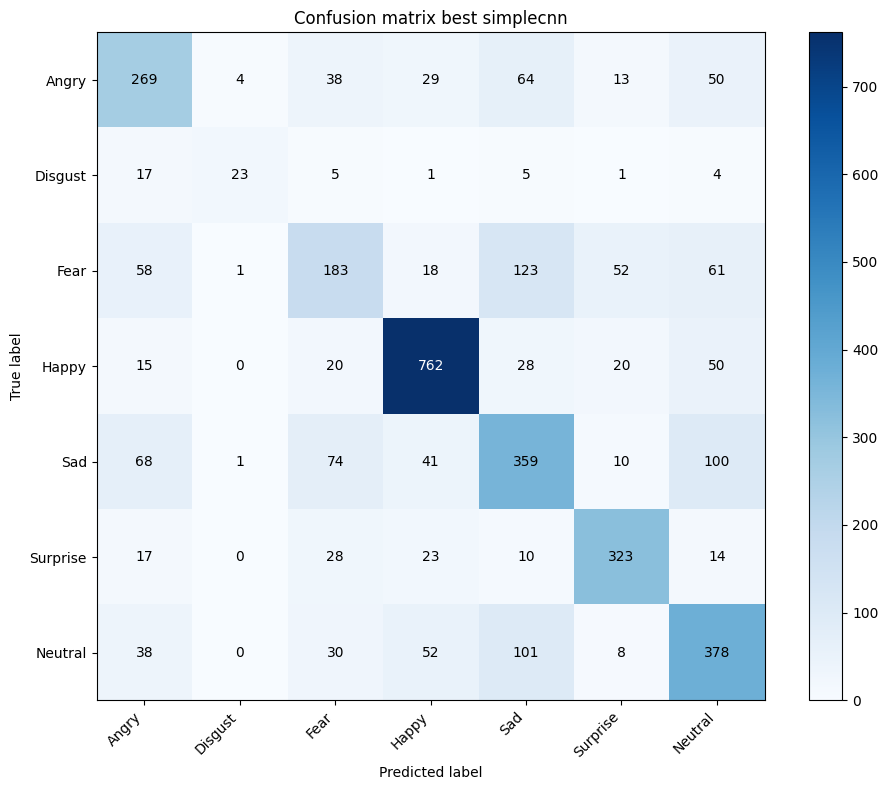

In [19]:
model_k5.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_k5(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.set_yticklabels(emotion_labels)

for i in range(7):
    for j in range(7):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_title('Confusion matrix best simplecnn')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.savefig('simplecnn_confusion_matrix.png', dpi=150)
plt.show()

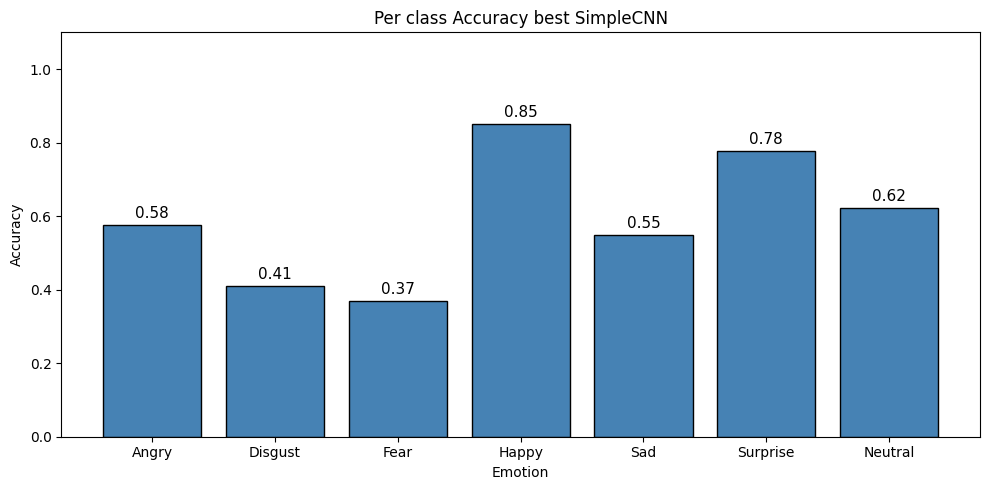

In [20]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(emotion_labels, per_class_acc, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Per class Accuracy best SimpleCNN')
ax.set_xlabel('Emotion')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('simplecnn_per_class_accuracy.png', dpi=150)
plt.show()